In [2]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

In [3]:
train_path = "../dataset/Brain tumor/Training"
test_path = "../dataset/Brain tumor/Testing"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [6]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

In [7]:
base_model.trainable = False

In [8]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        4,
        activation="softmax"
    )

])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [11]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.7764 - loss: 0.5603 - val_accuracy: 0.8319 - val_loss: 0.5125
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.8737 - loss: 0.3403 - val_accuracy: 0.8600 - val_loss: 0.4575
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.8939 - loss: 0.2831 - val_accuracy: 0.8675 - val_loss: 0.4406
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.9100 - loss: 0.2432 - val_accuracy: 0.8619 - val_loss: 0.4942
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9168 - loss: 0.2211 - val_accuracy: 0.8700 - val_loss: 0.4750
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9287 - loss: 0.1920 - val_accuracy: 0.8919 - val_loss: 0.4176
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.9293 - loss: 0.1768 - val_accuracy: 0.8775 - val_loss: 0.5438
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.9350 - loss: 0.1632 - val_accu

In [12]:
model.save("../models/brain_tumor_mobilenetv2.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [13]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "../models/mobilenet_training_history.csv",
    index=False
)

print("Training History Saved!")

Training History Saved!


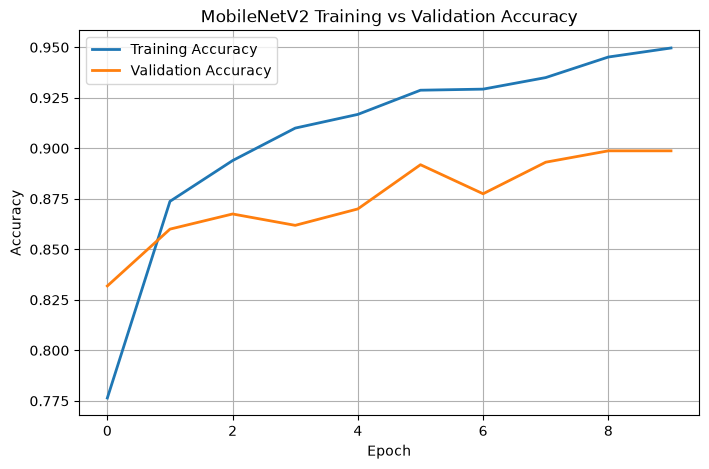

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("MobileNetV2 Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

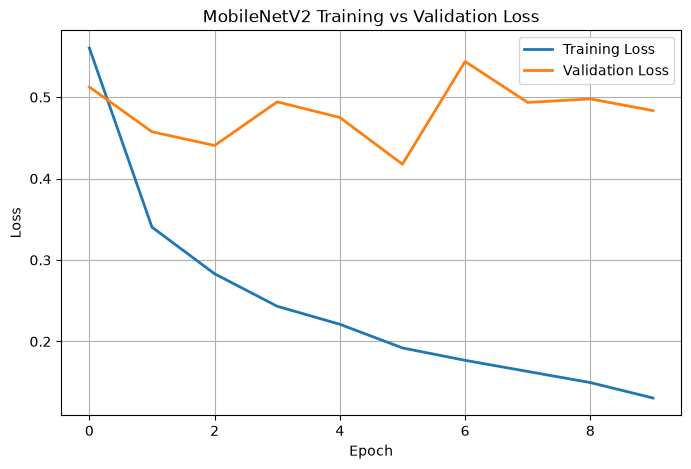

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("MobileNetV2 Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8988 - loss: 0.4834
Test Loss: 0.4834
Test Accuracy: 0.8988
